langkah 1
Memunculkan jumlah (baris, kolom)
Shape: (150, 5)
Memunculkan jenis tipe data
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
Memunculkan data yang diatas saja
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Memunculkan nilai-nilai statistika dasar
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100

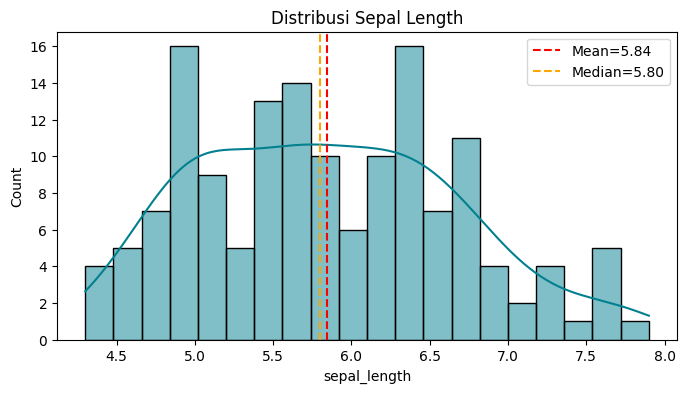

Langkah 4


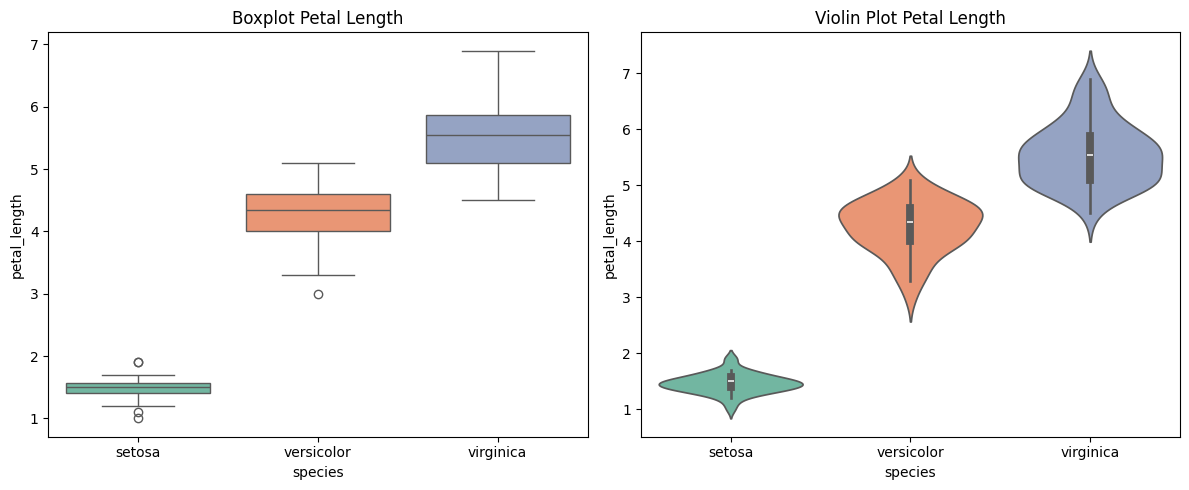


Langkah 5
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963

Langkah 6


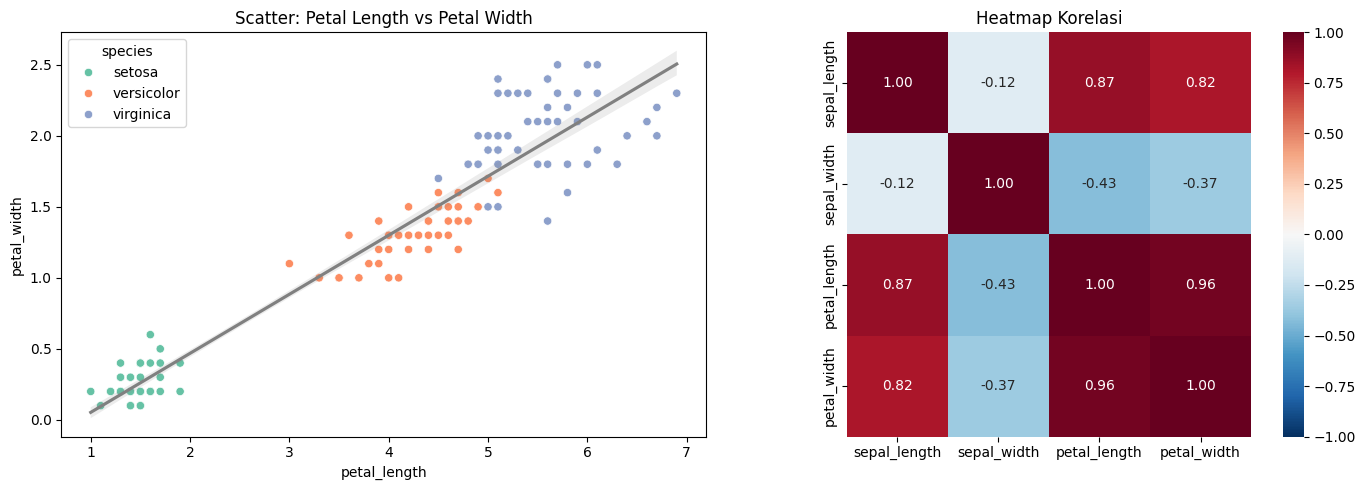

In [17]:
#Nama   : Muhammad Farras Ibnu Budiyanto
#Nim    : 240401010085
#Kelas  : IF404

#===================================
# STATISTIKA DASAR DAN ANALISIS DATA
#===================================

#Langkah 1 load dan inspect dataset
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
print("langkah 1")
df = sns.load_dataset('iris') #Load data
print("Memunculkan jumlah (baris, kolom)")
print('Shape:', df.shape) #memunculkan jumlah (baris,kolom)
print("Memunculkan jenis tipe data")
print(df.dtypes) #Memunculkan jenis tipe data
print("Memunculkan data yang diatas saja")
print(df.head()) #Memunculkan data yang berada diatas saja
print("Memunculkan nilai-nilai statistika dasar")
print(df.describe().round(3))  #Memunculkan nilai-nilai statistika dasar

#Langkah 2: Analisis Statistik Deskriptif lengkap
print("\n===============")
print("langkah 2")
print("="*15)
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'=== {col_name} ===')
    print(f' mean     : {col.mean():.3f}')  #memunculkan nilai mean (rata-rata)
    print(f' median   : {col.median():.3f}') #memunculkan nilai tengah
    print(f' std Dev  : {col.std():.3f}') #memunculkan standart deviasi
    print(f' skewness : {col.min():.3f}') #memunculkan nilai skewness (tingat ketidaksimetrisan data/ kemiringan)
    print(f' kurtosis : {col.max():.3f}') #memunculkan nilai kurtosis (tingkat keruncingan atau ketebalan ekor kurva dalam distribusi data)

#Langkah 3: Menggambar grafik
print("\nLangkah 3")
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()
#plt.subplots digunakan untuk memecah grafik menjadi fig(jendela utama grafik) dan ax (area plot dibuat)
#figsize digunakan untuk menyesuaikan ukuran grafik dalam inci/inch (lebar, tinggi)
#sns.histplot digunakan untuk menggambar histogram dari dataframe sepal lenght
#bins=20 digunakan untuk mengelompokkan data menjadi 20 kelompok. bins bebas diatur berapa saja.
#ax.axvline digunakan untuk membuat garis tegak lurus untuk nilai mean dan median dari dataframe sepal_lenght
#linestyle digunakan untuk menunjukkan model garis yang akan dibuat
#ax.set_title digunakan untuk memberi judul diatas grafik
#ax.legend() digunakan untuk memunculkan kotak legenda dipojok untuk menaruh label
#plt.show() digunakan untuk memunculkan gambar grafik secara utuh yang telah diminta

#Langkah 4: Boxplot per spesies
print("Langkah 4")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length', hue='species', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length', hue='species', palette='Set2', inner='box', legend=False, ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout(); plt.show()
#plt.subplots digunakan untuk memecah grafik menjadi fig(jendela utama grafik) dan ax (area plot dibuat)
#figsize digunakan untuk menyesuaikan ukuran grafik dalam inci/inch (lebar, tinggi)
#sns.boxplot digunakan untuk menggambar grafik boxplot untuk melihat ringkasan statistik dan outlier data
#hue='species' digunakan untuk menegaskan pengelompokan warna visual berdasarkan kategori spesies bunga
#palette='Set2' digunakan untuk menentukan tema palet warna (kombinasi warna pastel) dalam batang grafik
#legend=False digunakan untuk menyembunyikan kotak legenda karena informasi kategori sudah jelas tertera
#sns.violinplot digunakan untuk menggambar grafik violin plot untuk melihat kepadatan distribusi dan bentuk penyebaran data
#inner='box' digunakan untuk memunculkan komponen boxplot mini di dalam struktur utama violin plot

#Langkah 5: Matriks dan Korelasi pearson
print("\nLangkah 5")
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))
import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')
#df.drop('species') digunakan untuk membuang kolom species karena matriks korelasi kan cuman bisa angka.
#.corr(method='pearson) digunakan untuk membuat matriks korelasi menggunakan methode pearson
#(corr.round(3)) untuk menunjukkan nilai desimal, maksimal 1:1000 atau 0,000
#np.triu membuat nilai segitiga pada matriks korelasi dan garis diagonal menjadi nilai true, sedangkan segitiga bawah menjadi false
#corr_masked = corr.where(~mask) digunakan untuk menghapus nilai segitiga atas dan garis korelasi. Namun menyisakan segitiga bawah
#max_pair = corr_masked.stack().idxmax() digunakan untuk mencari nilai tertinggi


#Langkah 6
print("\nLangkah 6")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()
# sns.scatterplot digunakan untuk menggambar grafik titik (scatter plot) hubungan antar variabel berdasarkan spesies
# sns.regplot digunakan untuk menarik garis tren linear (garis lurus) di atas scatter plot yang sudah ada
# annot=True digunakan untuk memunculkan angka nilai korelasi di dalam kotak-kotak heatmap


In [19]:
#Setelah dianalisis melalui headmap matriks korelasi menunjukkan bahwa data dengan berwarna merah memiliki korelasi positif kuat, sedangkan berwarna biru memiliki korelasi negatif yang kuat pula
#Bisa dilihat bahwa petal_width dengan petal_Lenght mempunyai korelasi positif yang kuat yaitu di angka 0.96
#Interpretasi hubungan variabel:
#1. Grafik scatterplot membuktikan bahwa angka korelasi 0.96 terbukti benar karena semakin panjang garis lurus maka titik-titik akan semakin condong ke atas.
#2. Pemisahan class 'spesies'
## untuk bunga setosa (titik berwarna hijau) menunjukkan bahwa ia memiliki karateristik kelopak bunga yang kecil dan pendek
## untuk bunga versicolor (titik berwarna merah) menunjukkan bahwa ia memiliki karateristik yang sedang
## untuk bunga virginica (titik biru) menunjukkan bahwa ia memiliki karateristik yang besar

In [ ]:
#kesimpulan
#pada pertemuan ini kita mengetahui bagaimana load dataset
#pada pertemuan ini kita dapat mendeskripsikan data statistik dasar
#pada pertemuan ini kita diajarkan bagaimana caranya menggambar grafik menggunakan matplotlib nalisis univariat)(a
#pada pertemuan ini kita diajarkan cara menganalisis univariat
#pada pertemuan ini kita diajarkan cara menganalisis bivariat